# E03. Evaluate Lineups
- This evaluates contest results
- Type: Evaluation
- Run Frequency: Irregular
- Sources:
    - DraftKings
- Created: 3/30/2024
- Updated: 8/5/2025

### Imports

In [1]:
from DataImports import *

### Payouts

This assigns payouts to entrant lineups

In [2]:
# Assign payouts to existing contest lineups
def add_payouts(contestKey):
    # Read in DraftKings actual contest entries
    entry_scores = pd.read_csv(os.path.join(baseball_path, "A09. DraftKings", "5. Entry Results", f"Entry Results {contestKey}.csv"), encoding='iso-8859-1')
    entry_scores['Rank'] = entry_scores['Rank'].astype('int')

    # Read in Payouts
    payouts = pd.read_csv(os.path.join(baseball_path, "A09. DraftKings", "3. Payouts", f"Payouts {contestKey}.csv"), encoding='iso-8859-1')

    # Convert payouts to numeric
    payouts['payoutDescription'] = payouts['payoutDescription'].str.replace(',', '').str.replace('$', '').astype(float)
    
    # Rename 
    payouts.rename(columns={'minPosition':'Lower', 'maxPosition':'Upper', 'payoutDescription':'Payout'}, inplace=True)
    
    # Keep relevant variables
    payouts = payouts[['Lower', 'Upper', 'Payout']]
    
    
    # Loop over column rows
    for i, row in entry_scores.iterrows():
        rank = row['Rank']
        mask = (payouts['Lower'] <= rank) & (rank <= payouts['Upper'])
        if mask.any():
            payout = payouts.loc[mask, 'Payout'].values[0]
        else:
            payout = 0
        # Assign payout if Rank in range [Lower, Upper]
        entry_scores.at[i, 'Payout'] = payout

    return entry_scores

In [3]:
# add_payouts(161311521).head(1)

### Evaluate My Lineups

This assigns scores and payouts to my lineups

In [4]:
# Read in lineup sims and assign points
def calculate_lineup_returns(contestKey):
    # Read in Contest Guide
    guide = pd.read_csv(os.path.join(baseball_path, "B03. Contest Guides", f"Contest Guide {contestKey}.csv"))


    # Extract information from contest guide
    entryFee = guide['entryFee'][0]
    draftGroupId = guide['draftGroupId'][0]
    date = guide['date'][0]
    
    # Read in lineup sims
    sims = pd.read_csv(os.path.join(baseball_path, "C02. Optimization", "3. Lineups Ranked", f"Lineups Ranked {contestKey}.csv"), encoding='iso-8859-1')
    
    # Read in players and opponent lineups
    entry_scores = add_payouts(contestKey)

    # Read in player scores
    player_scores = pd.read_csv(os.path.join(baseball_path, "A09. DraftKings", "6. Player Results", f"Player Results {contestKey}.csv"), usecols=['Player', 'FPTS'], encoding='iso-8859-1')
    
    
    # For each position, merge the player's point total
    points_list = []
    for pos in ['P', 'P.1', 'C', '1B', '2B', '3B', 'SS', 'OF', 'OF.1', 'OF.2']:
        # Merges on name only, remove numeric characters
        sims[pos] = sims[pos].str.replace(r'[(0-9)]', "", regex=True)
        sims[pos] = sims[pos].str.rstrip()
        
        # Merge with points
        sims = sims.merge(player_scores, left_on=pos, right_on='Player', how='left')
        points_name = 'FPTS' + "_" + pos
        points_list.append(points_name)
        sims.drop(columns={'Player'},inplace=True)
        sims.rename(columns={'FPTS':points_name},inplace=True)
        
    # May duplicate if multiple players have the same name, usually want the first
    sims.drop_duplicates(subset=['P', 'P.1', 'C', '1B', '2B', '3B', 'SS', 'OF', 'OF.1', 'OF.2'], keep='first', inplace=True)
    sims.reset_index(inplace=True, drop=True)

    # Calculate lineup points
    sims['Points'] = sims[points_list].sum(axis=1)
    
    sims['Rank'] = np.nan
    sims['Payout'] = np.nan
    for index, row in sims.iterrows():
        points = row['Points']
        eligible = entry_scores[entry_scores['Points'] < points]

        if eligible.empty:
            # Lineup scored worse than all payout thresholds
            sims.at[index, 'Rank'] = entry_scores['Rank'].max()
            sims.at[index, 'Payout'] = 0.0
        else:
            match = eligible.iloc[0]
            sims.at[index, 'Rank'] = match['Rank']
            sims.at[index, 'Payout'] = match['Payout']


    # Convert to numeric
    sims['Payout'] = sims['Payout'].astype('float')
    
    # Rate of Return
    sims['entryFee'] = entryFee
    sims['Return'] = (sims['Payout'] / sims['entryFee']) - 1
    
    # Add contestKey
    sims['contestKey'] = contestKey
    sims['draftGroupId'] = draftGroupId
    sims['date'] = date
    sims['slate_size'] = guide.shape[0]

    return sims

In [5]:
def calculate_lineup_returns2(contestKey):
    try:
        return calculate_lineup_returns(contestKey)
    except:
        pass

In [6]:
# calculate_lineup_returns(161311521).head(1)

### Sample

In [7]:
# Create list of contestKeys with available guides
guide_contestKey_list = os.listdir(os.path.join(baseball_path, "B03. Contest Guides"))
guide_contestKey_list = [int(key.replace(".csv", "").split(" ")[2]) for key in guide_contestKey_list]

# Create list of contestKeys with available results
result_contestKey_list = os.listdir(os.path.join(baseball_path, "A09. DraftKings", "6. Player Results"))
result_contestKey_list = [int(key.replace(".csv", "").split(" ")[2]) for key in result_contestKey_list]

# Create list of contestKeys with available Payouts
payout_contestKey_list = os.listdir(os.path.join(baseball_path, "A09. DraftKings", "3. Payouts"))
payout_contestKey_list = [int(key.replace(".csv", "").split(" ")[1]) for key in payout_contestKey_list]

# Create a list of contestKeys with optimized lineups
lineup_contestKey_list = os.listdir(os.path.join(baseball_path, "C02. Optimization", "3. Lineups Ranked"))
lineup_contestKey_list = [int(key.replace(".csv", "").split(" ")[2]) for key in lineup_contestKey_list]

# Find the overlap 
available_contestKey_list = list(set(result_contestKey_list) & set(guide_contestKey_list) & set(payout_contestKey_list) & set(lineup_contestKey_list))

In [8]:
%%time
sims_list = Parallel(n_jobs=-1, verbose=1)(delayed(calculate_lineup_returns2)(contestKey) for contestKey in available_contestKey_list)
all_sims_df = pd.concat(sims_list, axis=0)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   23.8s
[Parallel(n_jobs=-1)]: Done 428 out of 428 | elapsed:  1.2min finished


CPU times: total: 1min 9s
Wall time: 1min 49s


### Evaluate Metrics
Metrics: <br>
- AvgPointsPerGame: Average projection
- Sim STD: Standard deviation of all lineup projections
- Plus#: AvgPointsPerGame + # * Sim STD
- Tail: Sum of projections from 95th-100th percentile
- Choose: Rarity Rank + Tail Rank 
- Choose2: Batter Rarity Rank + Tail Rank

In [9]:
def add_metrics(payout_df):
    # We want reverse ranks for ownership stats
    payout_df['Rarity'] = payout_df['rostership'] * -1 
    payout_df['Batter'] = payout_df['batter rostership'] * -1 
    payout_df['Pitcher'] = payout_df['pitcher rostership'] * -1 

    # Calculate rank
    for metric in ['AvgPointsPerGame', 'Sim STD', 'Plus2', 'Plus3', 'Tail', 'Rarity', 'Batter', 'Pitcher']:
        print(metric)
        payout_df.sort_values(['contestKey', metric], ascending=False, inplace=True)
        payout_df[f'{metric} Rank'] = payout_df.groupby('contestKey').cumcount() + 1

    # Add together rarity and tail ranks
    payout_df['Choose'] = payout_df['Rarity Rank'] + payout_df['Tail Rank']
    payout_df['Choose2'] = payout_df['Batter Rank'] + payout_df['Tail Rank']

    for metric in ['Choose', 'Choose2']:
        print(metric)
        payout_df.sort_values(['contestKey', metric], ascending=True, inplace=True)
        payout_df[f'{metric} Rank'] = payout_df.groupby('contestKey').cumcount() + 1
        
    return payout_df

In [10]:
all_sims_df = add_metrics(all_sims_df)

AvgPointsPerGame
Sim STD
Plus2
Plus3
Tail
Rarity
Batter
Pitcher
Choose
Choose2


In [11]:
def evaluate_metric(payout_df, metric, lineups=10):   
    # Sort by metric
    payout_df.sort_values(metric, ascending=True, inplace=True)
    # Select the top n lineup 
    group = payout_df.groupby('contestKey')['Return'].head(lineups)

    # Calculate average profit
    profit = group.mean()

    return profit

### Main Result
If I enter my typical {lineups} lineups per night, which approach is the most profitable?

In [12]:
metrics = ['AvgPointsPerGame', 'Sim STD', 'Plus2', 'Plus3', 'Tail', 'Rarity', 'Batter', 'Pitcher', 'Choose', 'Choose2']
lineups = 20

for metric in metrics:
    profit = evaluate_metric(all_sims_df, metric, lineups)
    print("With the {} metric, the top {} lineups would average a profit of {:.2f}.".format(metric, lineups, profit))

With the AvgPointsPerGame metric, the top 20 lineups would average a profit of -0.69.
With the Sim STD metric, the top 20 lineups would average a profit of -0.73.
With the Plus2 metric, the top 20 lineups would average a profit of -0.73.
With the Plus3 metric, the top 20 lineups would average a profit of -0.72.
With the Tail metric, the top 20 lineups would average a profit of -0.74.
With the Rarity metric, the top 20 lineups would average a profit of -0.25.
With the Batter metric, the top 20 lineups would average a profit of -0.24.
With the Pitcher metric, the top 20 lineups would average a profit of -0.30.
With the Choose metric, the top 20 lineups would average a profit of 0.06.
With the Choose2 metric, the top 20 lineups would average a profit of 0.04.


Do pareto-optimal lineups outperform the rest?

In [13]:
all_sims_df['pareto'] = paretoset(all_sims_df[["AvgPointsPerGame", "Sim STD", 'batter rostership', 'contestKey']], sense=['max', 'max', 'min', 'diff']).astype('int')

In [14]:
def pareto_ttest(df):
    # Perform t-test
    t_stat, p_value_t = ttest_ind(df[df['pareto'] == 0]['Return'],
                                   df[df['pareto'] == 1]['Return'])

    # Perform Mann-Whitney U test (non-parametric test for non-normally distributed data)
    u_stat, p_value_u = mannwhitneyu(df[df['pareto'] == 0]['Return'],
                                     df[df['pareto'] == 1]['Return'])

    print("T-test p-value:", p_value_t)
    print("Mann-Whitney U test p-value:", p_value_u)


In [15]:
pareto_ttest(all_sims_df)

T-test p-value: 9.865005872469299e-30
Mann-Whitney U test p-value: 2.4901397182261348e-111


In [16]:
all_sims_df.groupby('pareto')['Return'].quantile([0.9, 0.95, 0.99])

pareto          
0       0.900000    1.000000
        0.950000    1.500000
        0.990000    5.250000
1       0.900000    1.500000
        0.950000    2.750000
        0.990000   11.500000
Name: Return, dtype: float64

In [17]:
all_sims_df.groupby('pareto')[['Payout', 'entryFee', 'Return']].mean()

,Payout,entryFee,Return
pareto,,,
0,2.675282,4.000000,-0.331179
1,4.387587,4.000000,0.096897


### Regression

In [18]:
# Step 1: Choose variables
X = all_sims_df[['Tail Rank', 'Rarity Rank']]
y = all_sims_df['Return']

# Step 2: Add a constant term to the input features
X = sm.add_constant(X)

# Step 3: Create and fit the OLS model
model = sm.OLS(y, X)
results = model.fit()

# Step 4: Print the summary
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     602.3
Date:                Fri, 20 Feb 2026   Prob (F-statistic):          3.55e-262
Time:                        12:14:54   Log-Likelihood:            -3.4739e+06
No. Observations:             1137547   AIC:                         6.948e+06
Df Residuals:                 1137544   BIC:                         6.948e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0087      0.015      0.592      0.554      -0.020       0.037
Tail Rank      -0.0002   6.09e-06    -34.098      0.000      -0.000      -0.000
Rarity Rank -3.146e-05   6.09e-06     -5.169      0.000   -4.34e-05   -1.95e-05
==============================================================================
Omnibus:                  3801622.864   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):    1280163660166.193
Skew:                          59.472   Prob(JB):                         0.00
Kurtosis:                    5198.650   Cond. No.                     6.35e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.35e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Conclusion: worse ranked lineups do perform worse, on average, but it's not statistically significant. <br>
Expected payout for any additional lineups is below $4, so adding lineups isn't necessarily wise, at this moment.

### Plot

In [19]:
def plot_payouts(payout_df, metric):
    # Take average by rank
    df = payout_df.groupby([f'{metric} Rank'])['Return'].mean().reset_index()

    # Graph it
    plt.scatter(df[f'{metric} Rank'], df['Return'])

    # Fit line
    coefficients = np.polyfit(df[f'{metric} Rank'], df['Return'], 1)
    p = np.poly1d(coefficients)
    plt.plot(df[f'{metric} Rank'], p(df[f'{metric} Rank']), color='red', label='Trend line')

    # Labels and title
    plt.xlabel(f'{metric} Rank')
    plt.ylabel('Return')
    plt.title('Scatter Plot of Rank vs Return')

    # Display trend line equation
    equation = f'Return = {coefficients[0]:.2f} * Rank + {coefficients[1]:.2f}'
    plt.text(0.5, 0.9, equation, ha='center', va='center', transform=plt.gca().transAxes)

    # Legend and show plot
    plt.legend()
    plt.show()

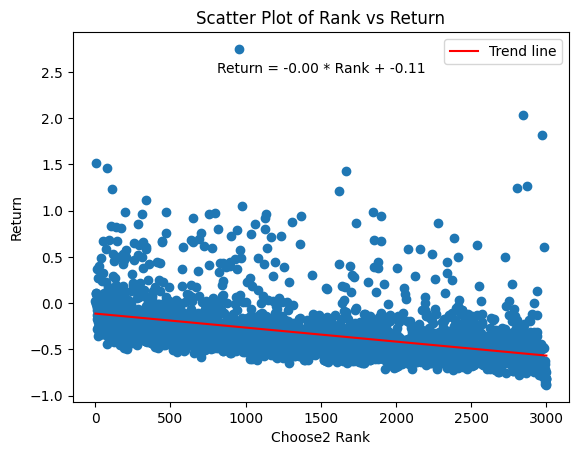

In [20]:
plot_payouts(all_sims_df, "Choose2")

Test a Lineup's Payouts

In [21]:
contestKey = 162596641
all_sims_df.query(f'contestKey == {contestKey}')[['P', 'P.1', 'C', '1B', '2B', '3B', 'SS', 'OF', 'OF.1', 'OF.2', 'Points', 'Rank', 'Payout', 'entryFee', 'Return', 'contestKey', 'draftGroupId', 'date']].to_csv(os.path.join(baseball_path, f"Payout Test {contestKey}.csv"), index=False)

In [22]:
all_sims_df.groupby('slate_size')['Return'].mean()

slate_size
2    -0.245873
3    -0.402692
4    -0.259080
5    -0.194568
6    -0.307859
7    -0.286007
8    -0.488605
9    -0.389806
10   -0.390127
11   -0.434462
12   -0.441665
13   -0.151812
14    0.151958
Name: Return, dtype: float64

In [23]:
all_sims_df['Profitable'] = np.where(all_sims_df['Return'] > 0, 1, 0)

all_sims_df.groupby('contestKey')['Profitable'].mean().describe()

count   428.000000
mean      0.208287
std       0.111484
min       0.002103
25%       0.130898
50%       0.193084
75%       0.261965
max       0.632139
Name: Profitable, dtype: float64

Lineup Choice
- Objective: Maximize profitability by selecting lineups based on their score and ownership projections

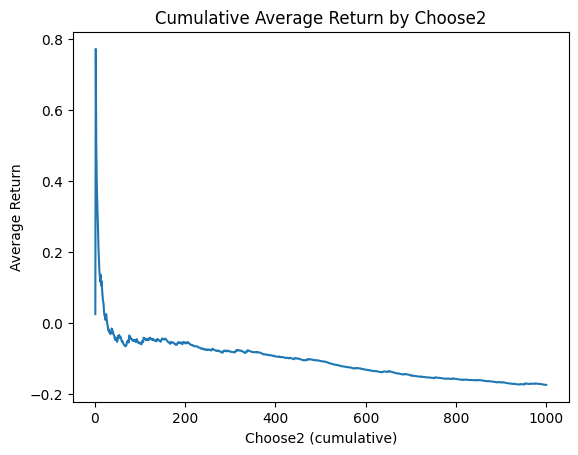

In [24]:
df = all_sims_df.query('`Choose2 Rank` <= 1000').sort_values("Choose2 Rank")

# cumulative mean of Return in Choose2 order
df["cum_avg_return"] = df["Return"].expanding().mean()

# one point per Choose2 value (take the last cumulative value for each)
plot_df = (
    df
    .groupby("Choose2 Rank", as_index=False)
    .last()[["Choose2 Rank", "cum_avg_return"]]
)

plt.figure()
plt.plot(plot_df["Choose2 Rank"], plot_df["cum_avg_return"])
plt.xlabel("Choose2 (cumulative)")
plt.ylabel("Average Return")
plt.title("Cumulative Average Return by Choose2")
plt.show()



In [25]:
all_sims_df[all_sims_df['Choose2 Rank'] <= 20][['entryFee', 'Payout', 'Return']].describe()

,entryFee,Payout,Return
count,8560.000000,8560.000000,8560.000000
mean,4.000000,4.154322,0.038581
std,0.000000,25.244242,6.311061
min,4.000000,0.000000,-1.000000
25%,4.000000,0.000000,-1.000000
50%,4.000000,0.000000,-1.000000
75%,4.000000,6.000000,0.500000
max,4.000000,1500.000000,374.000000


In [ ]:
# Maybe simulate entire field. Test optimized lineups against those. Calculate actual vs projected payouts